In [182]:
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import scipy.stats as sp

In [183]:
sample = np.load('formationchannels.npy')

(array([ 12.,  71., 146.,  99., 703., 513., 798., 487., 112.,   9.]),
 array([-4.965425  ,  0.40124195,  5.7679089 , 11.13457586, 16.50124281,
        21.86790976, 27.23457671, 32.60124366, 37.96791061, 43.33457757,
        48.70124452]),
 <BarContainer object of 10 artists>)

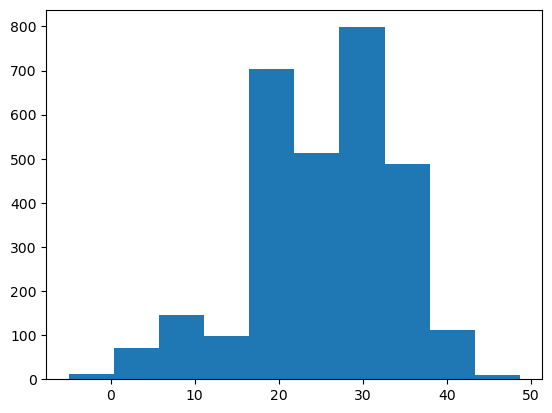

In [184]:
plt.hist(sample)

In [195]:
gm_fit = skl.mixture.GaussianMixture(n_components = 3).fit(sample)
xx = np.linspace(0,50,1000)

In [196]:
def calc_pdf_tot(x, n_comp): return np.sum(gm_fit.weights_[i] * sp.norm.pdf(x, loc=gm_fit.means_[i,0], scale=np.sqrt(gm_fit.covariances_[i,0,0])) for i in range(n_comp))

/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_35831/811713745.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  def calc_pdf_tot(x, n_comp): return np.sum(gm_fit.weights_[i] * sp.norm.pdf(x, loc=gm_fit.means_[i,0], scale=np.sqrt(gm_fit.covariances_[i,0,0])) for i in range(n_comp))


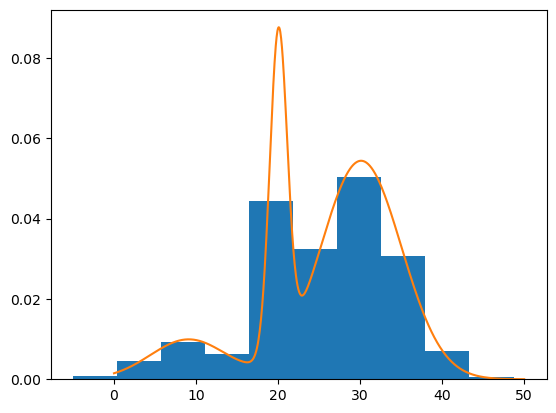

In [197]:
plt.hist(sample, density=True)
plt.plot(xx, calc_pdf_tot(xx, 3))
plt.show()

In [198]:
print(gm_fit.aic(sample))

20083.120259022795


* now implement the general case with a variable number of modes:

/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_35831/811713745.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  def calc_pdf_tot(x, n_comp): return np.sum(gm_fit.weights_[i] * sp.norm.pdf(x, loc=gm_fit.means_[i,0], scale=np.sqrt(gm_fit.covariances_[i,0,0])) for i in range(n_comp))
/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_35831/811713745.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  def calc_pdf_tot(x, n_comp): return np.sum(gm_fit.weights_[i] * sp.norm.pdf(x, loc=gm_fit.means_[i,0], scale=np.sqrt(gm_fit.covariances_[i,0,0])) for i in range(n_comp))
/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_35831/811713745.py:1: DeprecationWarning: Calling np.sum(generator) is deprec

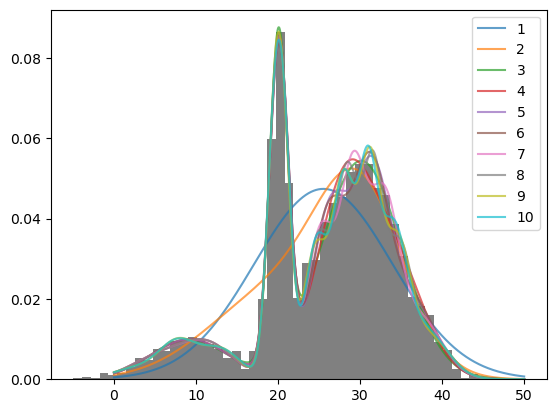

In [199]:
aic = np.ones(10)
for i in range(1,11):
    gm_fit = skl.mixture.GaussianMixture(n_components=i).fit(sample)
    plt.hist(sample, density=True, bins=50, color='gray')
    plt.plot(xx, calc_pdf_tot(xx, i), label=str(i), alpha=0.7) #
    aic[i-1] = gm_fit.aic(sample)
plt.legend()
plt.show()

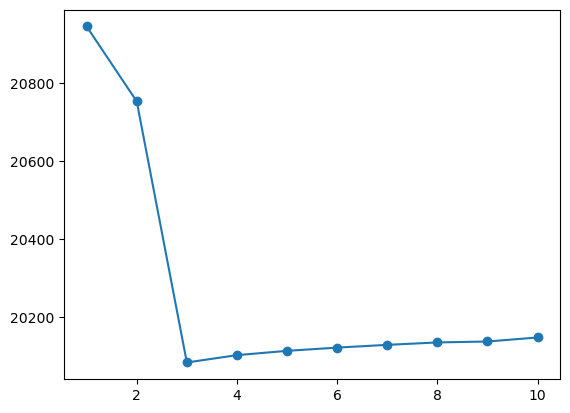

In [200]:
plt.plot(range(1,11), aic, marker='o')
plt.show()

In [201]:
print('best model #modes =', np.argmin(aic)+1)

best model #modes = 3


* clearly the model with 3 modes is the best

In [206]:
gm_fit = skl.mixture.GaussianMixture(n_components = 3).fit(sample)

/var/folders/qk/_k66m61n20l_yhkclqkkp8780000gn/T/ipykernel_35831/811713745.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  def calc_pdf_tot(x, n_comp): return np.sum(gm_fit.weights_[i] * sp.norm.pdf(x, loc=gm_fit.means_[i,0], scale=np.sqrt(gm_fit.covariances_[i,0,0])) for i in range(n_comp))


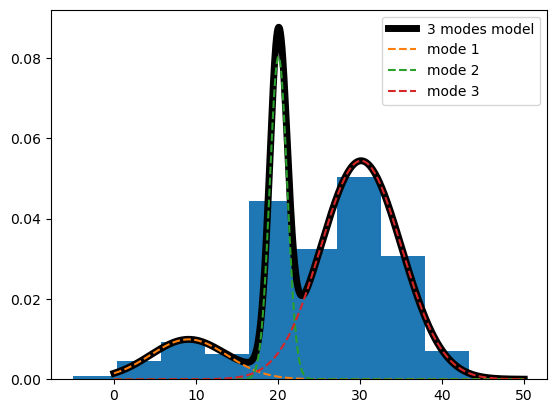

In [209]:
plt.hist(sample, density=True)
plt.plot(xx, calc_pdf_tot(xx, 3), c='black', label=str(np.argmin(aic)+1)+' modes model', linewidth=5)
for i in range(0,np.argmin(aic)+1): plt.plot(xx, gm_fit.weights_[i-1]*sp.norm.pdf(xx, loc=gm_fit.means_[i-1,0], scale=np.sqrt(gm_fit.covariances_[i-1,0,0])), ls='dashed', label='mode '+str(i+1))
plt.legend()
plt.show()